# Saudi Real Estate Market Analysis — 2024
**Type:** Descriptive Analytics (EDA) — no predictive modeling
**Source:** Saudi Ministry of Justice (MOJ) — official open real estate transaction data
**Tools:** Python (pandas, matplotlib, seaborn)

---
## 1. Business Question

> What are the patterns and trends in the Saudi real estate market during 2024, and
> how do prices, activity, and momentum differ by region — from both a market-overview
> and an **investment** perspective?

**Sub-questions:**
1. Which regions have the highest/lowest price per m²?
2. How strongly correlated are area and price, and does this vary by region?
3. What is the residential/commercial/agricultural mix per region?
4. Is there seasonality in transaction volume (e.g. around Ramadan)?
5. Which cities are most active by count and by total value?
6. Which regions offer the best liquidity vs. entry-price trade-off?
7. Which regions had the strongest price momentum (Q1 -> Q4)?
8. How concentrated is market liquidity?
9. How does residential vs. commercial mix vary by region?
10. What price segments (economy/mid/luxury) dominate each region?

## 2. Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

RAW_DIR = "/home/claude/real_estate_project/data"

frames = []
for q in ["Q1", "Q2", "Q3", "Q4"]:
    df_q = pd.read_csv(f"{RAW_DIR}/MOJ-Sales-2024-{q}.csv")
    df_q["quarter"] = q
    frames.append(df_q)
df = pd.concat(frames, ignore_index=True)
print("Raw shape:", df.shape)

Raw shape: (249331, 11)


In [2]:
df = df.rename(columns={
    "المنطقة": "region_ar", "المدينة": "city_ar", "المدينة / الحي": "district_ar",
    "الرقم المرجعي للصفقة": "ref_number", "تاريخ الصفقة ميلادي": "date_gregorian",
    "تاريخ الصفقة هجري": "date_hijri", "تصنيف العقار": "classification_ar",
    "عدد العقارات": "num_properties", "السعر": "price_raw", "المساحة": "area_raw",
})

before = len(df)
df = df.dropna(subset=["price_raw", "area_raw", "region_ar"])
print(f"Dropped {before - len(df)} rows with missing core fields")

df["price"] = df["price_raw"].astype(str).str.replace(",", "", regex=False).astype(float)
df["area_sqm"] = df["area_raw"].astype(str).str.replace(",", "", regex=False).astype(float)
df["date_gregorian"] = pd.to_datetime(df["date_gregorian"], format="%Y/%m/%d", errors="coerce")
df["month"] = df["date_gregorian"].dt.month
df["quarter_num"] = df["date_gregorian"].dt.quarter

for col in ["region_ar", "city_ar", "district_ar", "classification_ar"]:
    df[col] = df[col].astype(str).str.strip()

region_map = {
    "منطقة الرياض": "Riyadh", "منطقة مكة المكرمه": "Makkah", "منطقة الشرقية": "Eastern Province",
    "منطقة القصيم": "Qassim", "منطقة المدينة المنوره": "Madinah", "منطقة عسير": "Asir",
    "منطقة حائل": "Hail", "منطقة جازان": "Jazan", "منطقة تبوك": "Tabuk", "منطقة الجوف": "Al Jouf",
    "منطقة نجران": "Najran", "منطقة الحدود الشمالية": "Northern Borders", "منطقة الباحة": "Al Baha",
}
df["region"] = df["region_ar"].map(region_map)
classification_map = {"سكني": "Residential", "تجاري": "Commercial", "زراعي": "Agricultural"}
df["classification"] = df["classification_ar"].map(classification_map)

before = len(df)
df = df.drop_duplicates(subset=["ref_number"])
print(f"Dropped {before - len(df)} duplicate transactions")

before = len(df)
df = df[(df["price"] > 0) & (df["area_sqm"] > 0)]
print(f"Dropped {before - len(df)} rows with zero/negative price or area")

df["price_per_sqm"] = df["price"] / df["area_sqm"]

def iqr_flag(group, col, k=3):
    q1, q3 = group[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (group[col] >= lower) & (group[col] <= upper)

before = len(df)
mask = df.groupby("classification", group_keys=False).apply(lambda g: iqr_flag(g, "price_per_sqm"))
df = df[mask]
print(f"Dropped {before - len(df)} statistical outliers (IQR x3 on price/sqm)")

df = df.dropna(subset=["region", "classification", "date_gregorian"])
df_clean = df[["ref_number", "region", "city_ar", "district_ar", "classification",
                "num_properties", "price", "area_sqm", "price_per_sqm",
                "date_gregorian", "month", "quarter_num"]].copy()
print("Clean shape:", df_clean.shape)
df_clean.describe()

Dropped 3 rows with missing core fields


Dropped 0 duplicate transactions
Dropped 0 rows with zero/negative price or area


/tmp/ipykernel_505/463376868.py:49: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[mask]


Dropped 5457 statistical outliers (IQR x3 on price/sqm)
Clean shape: (243871, 12)


,ref_number,num_properties,price,area_sqm,price_per_sqm,date_gregorian,month,quarter_num
count,2.438710e+05,243871.000000,2.438710e+05,2.438710e+05,243871.000000,243871,243871.000000,243871.000000
mean,2.450529e+07,1.029171,9.513665e+05,4.239613e+03,1625.523181,2024-07-12 12:47:00.645341,6.874614,2.626397
min,2.115272e+07,1.000000,5.000000e+03,3.200000e+00,0.002500,2024-01-01 00:00:00,1.000000,1.000000
25%,2.324611e+07,1.000000,2.000000e+05,3.080000e+02,320.000000,2024-04-07 00:00:00,4.000000,2.000000
50%,2.457606e+07,1.000000,4.543000e+05,4.896000e+02,1011.904762,2024-07-25 00:00:00,7.000000,3.000000
75%,2.578416e+07,1.000000,8.500000e+05,6.917600e+02,2354.078735,2024-10-13 00:00:00,10.000000,4.000000
max,2.703526e+07,326.000000,2.274109e+09,2.400724e+07,9169.884170,2024-12-31 00:00:00,12.000000,4.000000
std,1.474636e+06,0.881098,8.198393e+06,8.735175e+04,1746.367023,NaN,3.507729,1.137335


## 3. Exploratory Data Analysis

### 3.1 Price per m² by Region

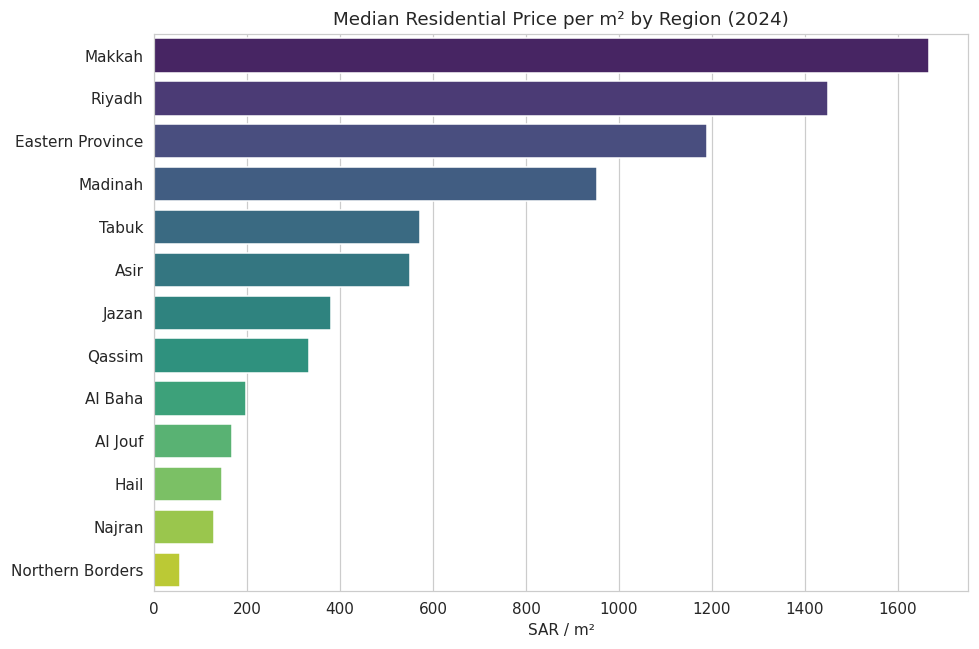

In [3]:
region_price = (df_clean[df_clean["classification"] == "Residential"]
                 .groupby("region")["price_per_sqm"].median().sort_values(ascending=False))
plt.figure(figsize=(9, 6))
sns.barplot(x=region_price.values, y=region_price.index, hue=region_price.index,
            palette="viridis", legend=False)
plt.title("Median Residential Price per m² by Region (2024)")
plt.xlabel("SAR / m²"); plt.ylabel("")
plt.tight_layout(); plt.show()

### 3.2 Area vs. Price Relationship

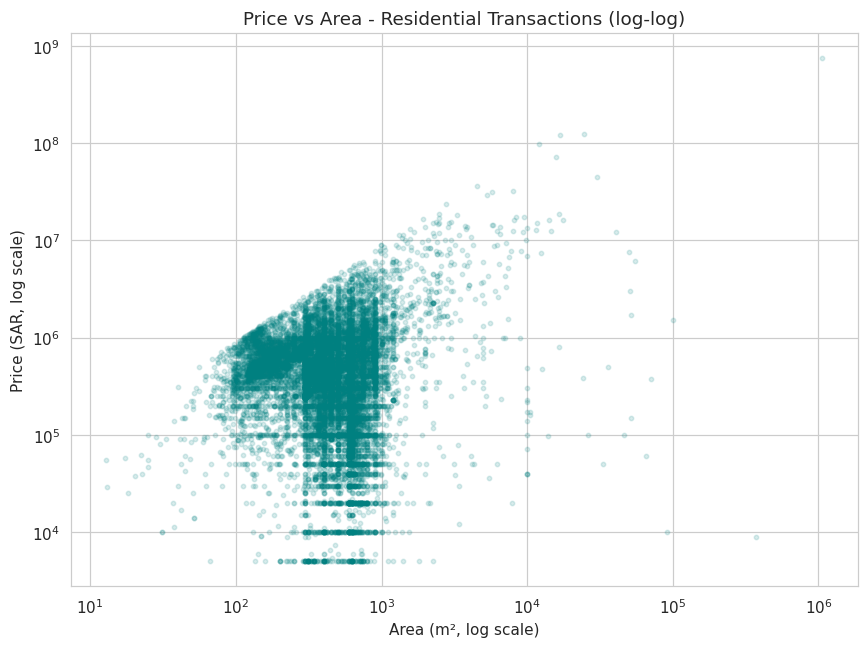

region
Tabuk               0.922723
Makkah              0.842210
Jazan               0.745029
Al Jouf             0.686873
Qassim              0.599086
Riyadh              0.575693
Asir                0.427101
Eastern Province    0.391173
Hail                0.329175
Northern Borders    0.208635
Al Baha             0.196318
Madinah             0.194910
Najran              0.078410
Name: price, dtype: float64

In [4]:
sample = df_clean[df_clean["classification"] == "Residential"].sample(15000, random_state=1)
plt.figure(figsize=(8, 6))
plt.scatter(sample["area_sqm"], sample["price"], alpha=0.15, s=8, color="teal")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Area (m², log scale)"); plt.ylabel("Price (SAR, log scale)")
plt.title("Price vs Area - Residential Transactions (log-log)")
plt.tight_layout(); plt.show()

corr_by_region = (df_clean[df_clean["classification"] == "Residential"]
                   .groupby("region")[["area_sqm", "price"]].corr().iloc[0::2, 1]
                   .droplevel(1).sort_values(ascending=False))
corr_by_region

### 3.3 Property Classification Mix by Region

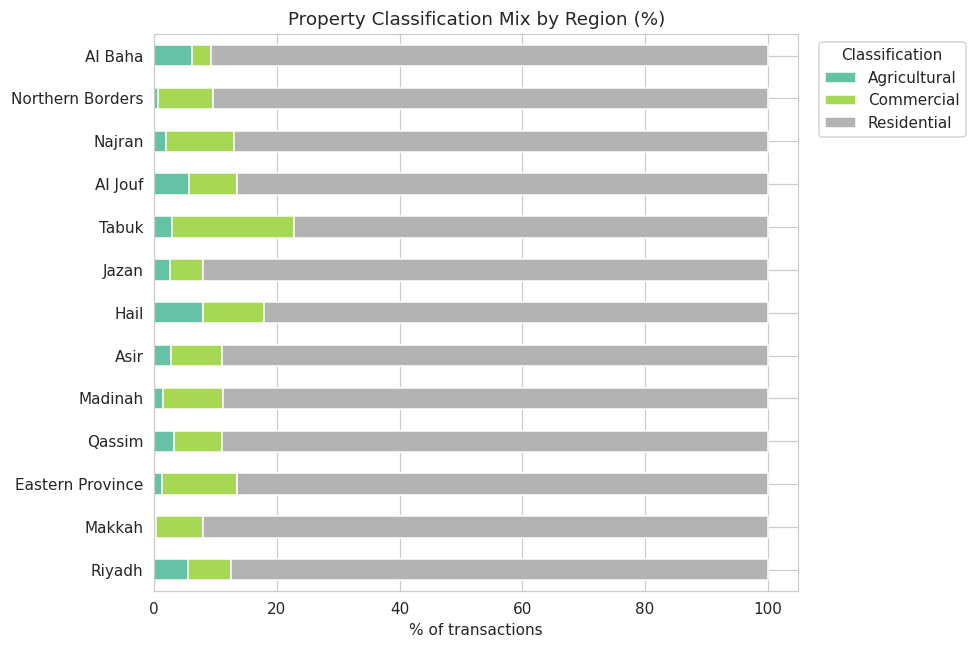

In [5]:
mix = pd.crosstab(df_clean["region"], df_clean["classification"], normalize="index") * 100
mix = mix.loc[df_clean["region"].value_counts().index]
mix.plot(kind="barh", stacked=True, figsize=(9, 6), colormap="Set2")
plt.title("Property Classification Mix by Region (%)")
plt.xlabel("% of transactions"); plt.ylabel("")
plt.legend(title="Classification", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

### 3.4 Seasonality — Monthly Transaction Volume

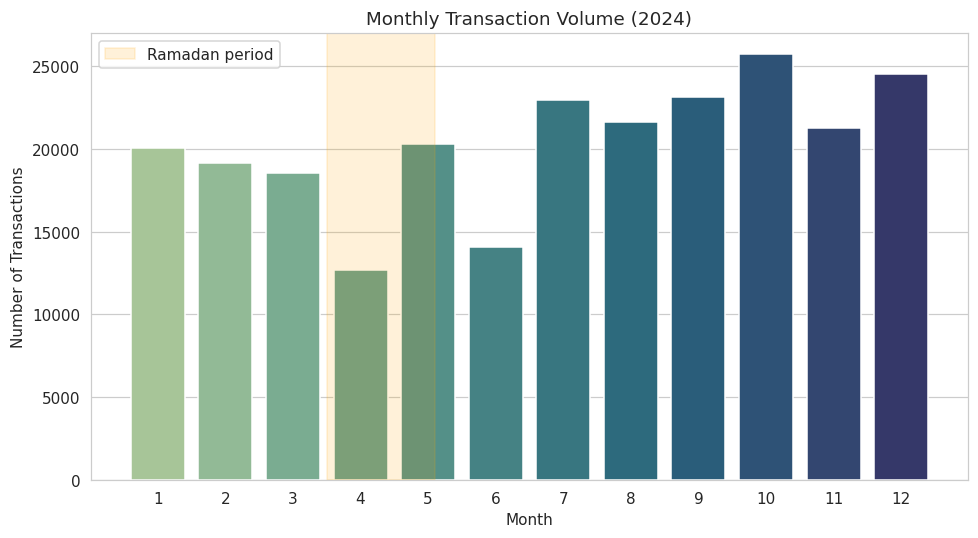

In [6]:
monthly = df_clean.groupby("month").size()
plt.figure(figsize=(9, 5))
sns.barplot(x=monthly.index, y=monthly.values, hue=monthly.index, palette="crest", legend=False)
plt.title("Monthly Transaction Volume (2024)")
plt.xlabel("Month"); plt.ylabel("Number of Transactions")
plt.axvspan(2.5, 4.1, color="orange", alpha=0.15, label="Ramadan period")
plt.legend(); plt.tight_layout(); plt.show()

### 3.5 Top Cities by Activity and Value

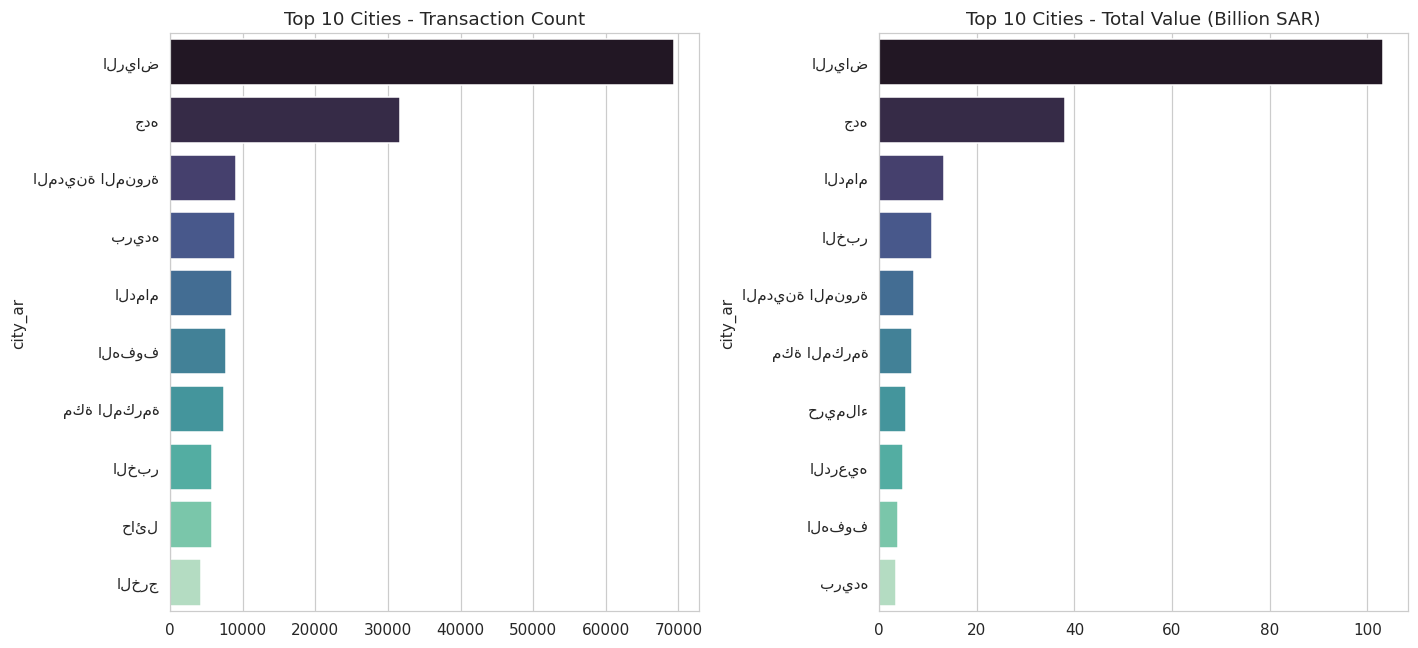

In [7]:
top_cities_count = df_clean["city_ar"].value_counts().head(10)
top_cities_value = df_clean.groupby("city_ar")["price"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(x=top_cities_count.values, y=top_cities_count.index, ax=axes[0],
            hue=top_cities_count.index, palette="mako", legend=False)
axes[0].set_title("Top 10 Cities - Transaction Count")
sns.barplot(x=(top_cities_value.values/1e9), y=top_cities_value.index, ax=axes[1],
            hue=top_cities_value.index, palette="mako", legend=False)
axes[1].set_title("Top 10 Cities - Total Value (Billion SAR)")
plt.tight_layout(); plt.show()

### 3.6 Price Momentum (Q1 -> Q4)

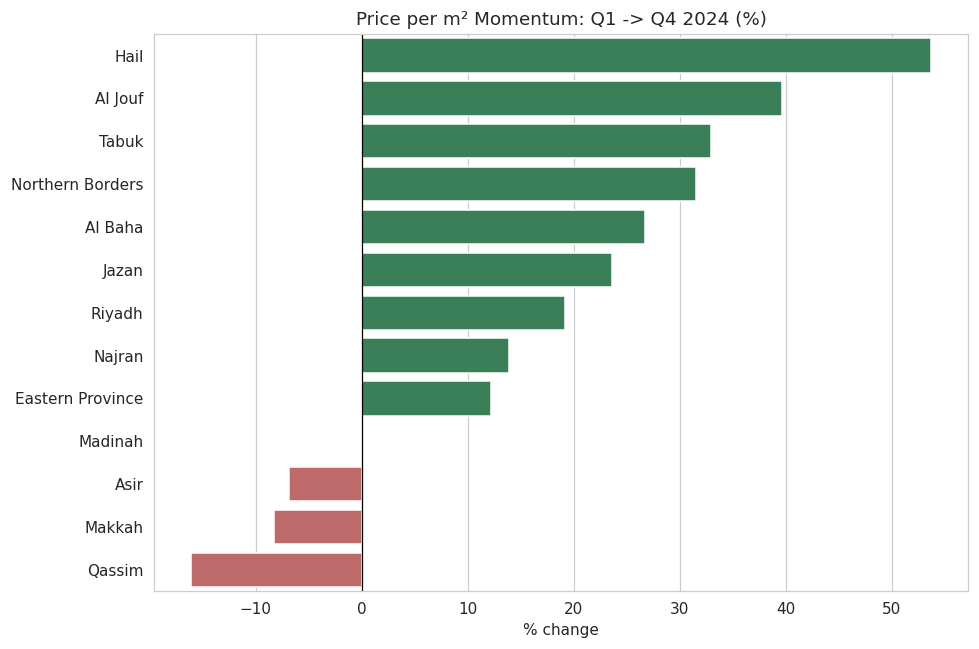

In [8]:
quarterly_region = (df_clean[df_clean["classification"] == "Residential"]
                     .groupby(["region", "quarter_num"])["price_per_sqm"].median().unstack())
quarterly_region["QoQ_change_%"] = ((quarterly_region[4] - quarterly_region[1]) / quarterly_region[1] * 100).round(1)
quarterly_region_sorted = quarterly_region.sort_values("QoQ_change_%", ascending=False)

plt.figure(figsize=(9, 6))
colors = ["seagreen" if v > 0 else "indianred" for v in quarterly_region_sorted["QoQ_change_%"]]
sns.barplot(x=quarterly_region_sorted["QoQ_change_%"], y=quarterly_region_sorted.index,
            hue=quarterly_region_sorted.index, palette=colors, legend=False)
plt.title("Price per m² Momentum: Q1 -> Q4 2024 (%)")
plt.xlabel("% change"); plt.ylabel("")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout(); plt.show()

### 3.7 Liquidity Heatmap

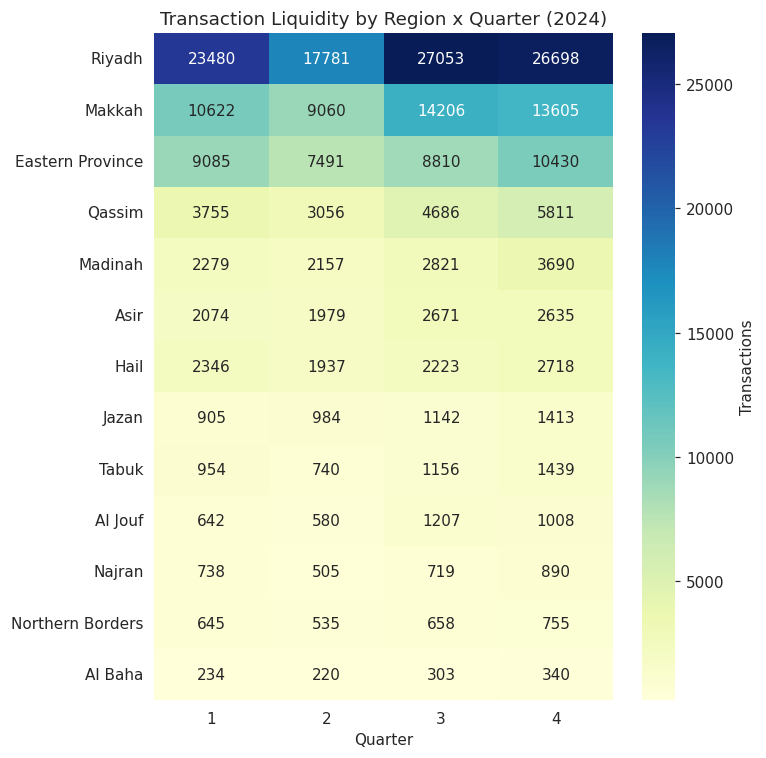

In [9]:
liquidity = pd.crosstab(df_clean["region"], df_clean["quarter_num"])
liquidity = liquidity.loc[liquidity.sum(axis=1).sort_values(ascending=False).index]
plt.figure(figsize=(7, 7))
sns.heatmap(liquidity, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Transactions"})
plt.title("Transaction Liquidity by Region x Quarter (2024)")
plt.xlabel("Quarter"); plt.ylabel("")
plt.tight_layout(); plt.show()

### 3.8 Price Segments by Region

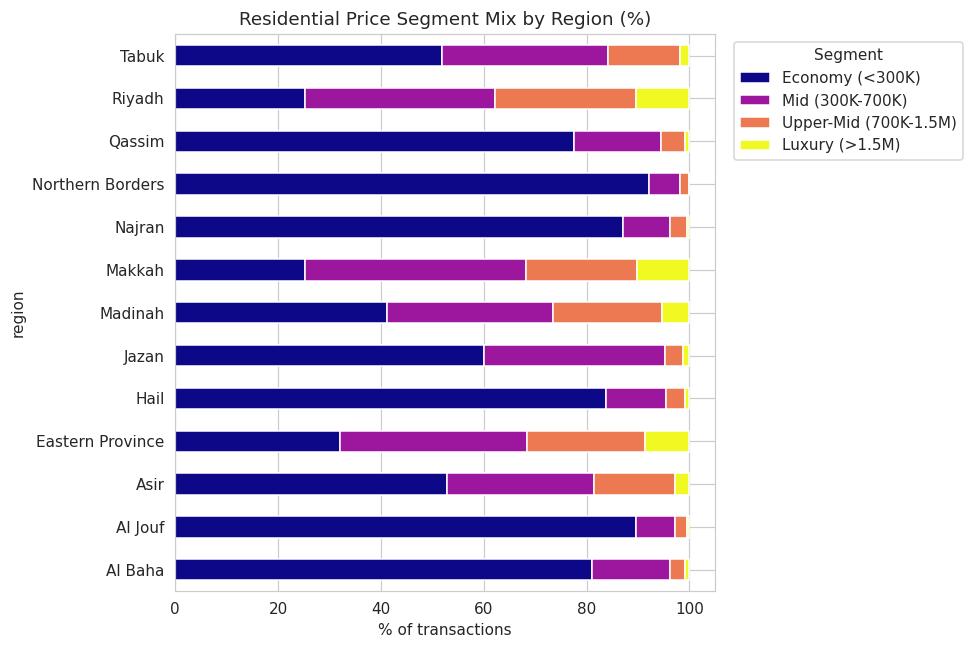

In [10]:
res = df_clean[df_clean["classification"] == "Residential"].copy()
bins = [0, 300000, 700000, 1500000, res["price"].max()]
labels = ["Economy (<300K)", "Mid (300K-700K)", "Upper-Mid (700K-1.5M)", "Luxury (>1.5M)"]
res["segment"] = pd.cut(res["price"], bins=bins, labels=labels)
segment_region = pd.crosstab(res["region"], res["segment"], normalize="index") * 100
segment_region.plot(kind="barh", stacked=True, figsize=(9, 6), colormap="plasma")
plt.title("Residential Price Segment Mix by Region (%)")
plt.xlabel("% of transactions")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 4. Key Insights

**Market Overview**
- Prices are concentrated in a top tier — Makkah (1,668 SAR/m²), Riyadh (1,450),
  Eastern Province (1,190), Madinah (952) — vs. a bottom tier as low as 55 SAR/m²
  (Northern Borders). This is a price cliff, not a smooth gradient.
- Area explains price strongly in some regions (Tabuk 0.92, Makkah 0.84) but weakly
  in others (Najran 0.08, Madinah 0.19) — location dominates over raw size in most
  of the country.
- Ramadan (April) produces a real ~32% dip in transaction volume nationwide, with
  an immediate rebound in May and a build-up toward a Q4 peak (October).
- Riyadh and Jeddah dominate both transaction count and total value; Riyadh alone
  is 28% of national volume and 41% of national value.

**Investment Angle**
- Price level and price momentum are independent: Hail (+54%), Al Jouf (+40%), and
  Tabuk (+33%) led 2024 price growth despite being low-priced regions, while Qassim
  (-16%) and Makkah (-8%) declined despite being high-priced.
- Liquidity is extremely concentrated — Riyadh's single busiest quarter exceeds the
  full-year volume of 9 of the 13 regions combined.
- A genuine "luxury" segment (>1.5M SAR) only exists meaningfully in Riyadh, Makkah,
  and Eastern Province; elsewhere the market is overwhelmingly Economy/Mid tier.

## 5. Business Recommendations

1. **Segment strategy by growth vs. stability** — target Hail/Al Jouf/Tabuk for
   capital appreciation, Riyadh/Eastern Province for liquidity and capital preservation.
2. **Treat Riyadh's liquidity dominance as a concentration risk** — diversify a
   portion of exposure into Makkah/Eastern Province to reduce single-market dependency.
3. **Time acquisitions around the Ramadan dip** — a lower-competition entry window
   for buyers; sellers should target the Q3-Q4 peak instead.
4. **Use area-price correlation strength as a due-diligence signal** — reliable
   price/m² comparisons in Tabuk/Makkah; unreliable in Najran/Madinah, where
   location-specific diligence is required.

*Scope note: all findings are descriptive, based on observed 2024 transactions only.
No predictive/forecasting model was used.*